In [1]:
#assignment 6
# pip install kagglehub pandas
import kagglehub, pandas as pd, os



In [2]:
#Malboure Datast
path = kagglehub.dataset_download("anthonypino/melbourne-housing-market")
print(os.listdir(path))
df = pd.read_csv(os.path.join(path, "Melbourne_housing_FULL.csv"))


100%|██████████| 2.28M/2.28M [00:00<00:00, 70.5MB/s]

Extracting files...
['MELBOURNE_HOUSE_PRICES_LESS.csv', 'Melbourne_housing_FULL.csv']


In [3]:
df

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra City Council,-37.80140,144.99580,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra City Council,-37.79960,144.99840,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.80790,144.99340,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.5,3067.0,...,2.0,1.0,0.0,NaN,NaN,Yarra City Council,-37.81140,145.01160,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.80930,144.99440,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34852,Yarraville,13 Burns St,4,h,1480000.0,PI,Jas,24/02/2018,6.3,3013.0,...,1.0,3.0,593.0,NaN,NaN,Maribyrnong City Council,-37.81053,144.88467,Western Metropolitan,6543.0
34853,Yarraville,29A Murray St,2,h,888000.0,SP,Sweeney,24/02/2018,6.3,3013.0,...,2.0,1.0,98.0,104.0,2018.0,Maribyrnong City Council,-37.81551,144.88826,Western Metropolitan,6543.0
34854,Yarraville,147A Severn St,2,t,705000.0,S,Jas,24/02/2018,6.3,3013.0,...,1.0,2.0,220.0,120.0,2000.0,Maribyrnong City Council,-37.82286,144.87856,Western Metropolitan,6543.0
34855,Yarraville,12/37 Stephen St,3,h,1140000.0,SP,hockingstuart,24/02/2018,6.3,3013.0,...,NaN,NaN,NaN,NaN,NaN,Maribyrnong City Council,NaN,NaN,Western Metropolitan,6543.0


In [4]:
print(df.shape)

(34857, 21)


In [5]:
#Check Nulls
df.isna().sum()

,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,7610
Method,0
SellerG,0
Date,0
Distance,1
Postcode,1


In [6]:
#Numeric ≥ 3 % missing
#BuildingArea 60.6%, YearBuilt 55.4%, Landsize 33.9%, Car 25.0%, Bathroom/Bedroom2 23.6%

R2: the audit table

In [7]:
import pandas as pd, numpy as np

df = df.dropna(subset=["Price"]).reset_index(drop=True)
X, y = df.drop(columns="Price"), df["Price"]

rows = []
for c in X.columns:
    s = X[c]
    r = {"column": c, "dtype": str(s.dtype),
         "%missing": round(s.isna().mean()*100, 1),
         "distinct": s.nunique()}
    if pd.api.types.is_numeric_dtype(s):
        q1, q3 = s.quantile([.25, .75])
        iqr = q3 - q1
        out = ((s < q1-1.5*iqr) | (s > q3+1.5*iqr)).mean()*100
        r["min/max or top3"] = f"{s.min():.4g} / {s.max():.4g}"
        r["outliers %"] = round(out, 1)
        r["skew"] = round(s.skew(), 2)
    else:
        r["min/max or top3"] = ", ".join(map(str, s.value_counts().head(5).index))
        r["outliers %"] = np.nan
        r["skew"] = np.nan
    rows.append(r)

audit = pd.DataFrame(rows)
print(audit.to_string(index=False))

       column   dtype  %missing  distinct                                                                                                          min/max or top3  outliers %  skew
       Suburb  object       0.0       345                                                                  Reservoir, Bentleigh East, Richmond, Preston, Brunswick         NaN   NaN
      Address  object       0.0     26751                                                   5 Charles St, 14 James St, 2 Bruce St, 53 William St, 36 Aberfeldie St         NaN   NaN
        Rooms   int64       0.0        12                                                                                                                   1 / 16         0.1  0.51
         Type  object       0.0         3                                                                                                                  h, u, t         NaN   NaN
       Method  object       0.0         5                                                      

In [8]:
import pandas as pd, numpy as np

# audit population: raw file, rows with a known target
d = df.dropna(subset=["Price"]).reset_index(drop=True)

treatment = {
 "Price":        "Target. Drop rows with missing Price at load; model log(Price) (right-skewed).",
 "Suburb":       "High cardinality, signal present -> out-of-fold target encoding inside the pipeline.",
 "Address":      "ID-like (about 1 distinct value per row) -> drop.",
 "Rooms":        "Skew 0.53 -> StandardScaler.",
 "Type":         "Low cardinality, not ordered -> one-hot (handle_unknown='ignore'); also the imputation grouping key.",
 "Method":       "Low cardinality -> one-hot (handle_unknown='ignore').",
 "SellerG":      "High cardinality, weak signal -> rare-grouped one-hot (min_frequency=20).",
 "Date":         "String -> parse with dayfirst=True inside the pipeline; use year and month.",
 "Distance":     "Skew 1.48 -> log1p + StandardScaler; impute median (1 row missing).",
 "Postcode":     "A code, not a quantity; Suburb covers it -> drop.",
 "Bedroom2":     "Near-duplicate of Rooms -> drop (show correlation).",
 "Bathroom":     "MAR (Type, Rooms) -> group-median by Type, shared block-B indicator, RobustScaler.",
 "Car":          "MAR (YearBuilt, Type) -> group-median by Type, shared block-B indicator, RobustScaler.",
 "Landsize":     "Keep real zeros + landsize_zero flag; MAR/MNAR-leaning -> group-median, indicator, clip p1/p99 -> Yeo-Johnson.",
 "BuildingArea": "0 impossible -> NaN; unresolved MAR/MNAR -> group-median, indicator, clip p1/p99 -> log1p + StandardScaler.",
 "YearBuilt":    "Values <1800 impossible -> NaN; MAR -> impute, indicator, StandardScaler.",
 "CouncilArea":  "33 categories, ~0% missing -> fill 'Unknown', one-hot with min_frequency=5.",
 "Lattitude":    "Missing with Longtitude and block B -> Suburb-median impute (fallback Regionname, global), shared indicator, StandardScaler.",
 "Longtitude":   "Same as Lattitude.",
 "Regionname":   "Low cardinality -> one-hot (handle_unknown='ignore').",
 "Propertycount":"Skew 1.02 -> log1p + StandardScaler; impute median (few rows missing).",
}

rows = []
for c in d.columns:
    s = d[c]
    r = {"column": c, "dtype": str(s.dtype),
         "% missing": round(s.isna().mean() * 100, 1),
         "distinct": s.nunique()}
    if pd.api.types.is_numeric_dtype(s):
        q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
        out = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).mean() * 100
        r["min / max or top 3"] = f"{s.min():.4g} / {s.max():.4g}"
        r["outliers"] = f"{out:.1f}% (IQR rule), skew {s.skew():.2f}"
    else:
        vc = s.value_counts()
        r["min / max or top 3"] = ", ".join(map(str, vc.head(3).index))
        r["outliers"] = f"n/a; {vc[vc < 20].sum() / s.notna().sum():.1%} of rows in categories with count < 20"
    r["proposed treatment"] = treatment[c]
    rows.append(r)

audit = pd.DataFrame(rows)

pd.set_option("display.max_colwidth", None, "display.width", 250)
display(audit)                       # in Colab/Jupyter
audit.to_csv("audit_table.csv", index=False)
print(audit.to_markdown(index=False))   # paste into justification.md (needs: pip install tabulate)

,column,dtype,% missing,distinct,min / max or top 3,outliers,proposed treatment
0,Suburb,object,0.0,345,"Reservoir, Bentleigh East, Richmond",n/a; 3.0% of rows in categories with count < 20,"High cardinality, signal present -> out-of-fold target encoding inside the pipeline."
1,Address,object,0.0,26751,"5 Charles St, 14 James St, 2 Bruce St",n/a; 100.0% of rows in categories with count < 20,ID-like (about 1 distinct value per row) -> drop.
2,Rooms,int64,0.0,12,1 / 16,"0.1% (IQR rule), skew 0.51",Skew 0.53 -> StandardScaler.
3,Type,object,0.0,3,"h, u, t",n/a; 0.0% of rows in categories with count < 20,"Low cardinality, not ordered -> one-hot (handle_unknown='ignore'); also the imputation grouping key."
4,Price,float64,0.0,2871,8.5e+04 / 1.12e+07,"4.7% (IQR rule), skew 2.59",Target. Drop rows with missing Price at load; model log(Price) (right-skewed).
5,Method,object,0.0,5,"S, SP, PI",n/a; 0.0% of rows in categories with count < 20,Low cardinality -> one-hot (handle_unknown='ignore').
6,SellerG,object,0.0,349,"Nelson, Jellis, Barry",n/a; 4.2% of rows in categories with count < 20,"High cardinality, weak signal -> rare-grouped one-hot (min_frequency=20)."
7,Date,object,0.0,78,"28/10/2017, 17/03/2018, 9/12/2017",n/a; 0.2% of rows in categories with count < 20,String -> parse with dayfirst=True inside the pipeline; use year and month.
8,Distance,float64,0.0,213,0 / 48.1,"4.4% (IQR rule), skew 1.48",Skew 1.48 -> log1p + StandardScaler; impute median (1 row missing).
9,Postcode,float64,0.0,209,3000 / 3978,"2.9% (IQR rule), skew 3.98","A code, not a quantity; Suburb covers it -> drop."


| column        | dtype   |   % missing |   distinct | min / max or top 3                                                   | outliers                                          | proposed treatment                                                                                                           |
|:--------------|:--------|------------:|-----------:|:---------------------------------------------------------------------|:--------------------------------------------------|:-----------------------------------------------------------------------------------------------------------------------------|
| Suburb        | object  |         0   |        345 | Reservoir, Bentleigh East, Richmond                                  | n/a; 3.0% of rows in categories with count < 20   | High cardinality, signal present -> out-of-fold target encoding inside the pipeline.                                         |
| Address       | object  |         0   |      26751 | 5 Charles St, 14 James St, 2 B

R3: code and tables

In [9]:
#Part 1: mechanism evidence

import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split

d = df.dropna(subset=["Price"]).reset_index(drop=True)
X, y = d.drop(columns="Price"), np.log(d["Price"])
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

T = Xtr.copy()
T["YearBuilt"]    = T["YearBuilt"].where(T["YearBuilt"] >= 1800)
T["BuildingArea"] = T["BuildingArea"].where(T["BuildingArea"] > 0)
T["log_price"] = ytr

miss_cols = [c for c in T.columns if T[c].isna().any()]
num = T.select_dtypes("number").columns.drop("log_price")

def cohen_d(a, b):
    a, b = a.dropna(), b.dropna()
    sp = np.sqrt((a.var() + b.var()) / 2)
    return (a.mean() - b.mean()) / sp if sp > 0 else np.nan

ev = []
for c in miss_cols:
    m = T[c].isna()
    r = {"column": c, "n_missing": int(m.sum()), "% missing": round(m.mean()*100, 1)}
    if m.sum() < 30:
        r["evidence"] = f"only {m.sum()} rows missing: comparison untestable"
        ev.append(r); continue
    res = []
    for o in list(num.difference([c])) + ["log_price"]:
        a, b = T.loc[m, o].dropna(), T.loc[~m, o].dropna()
        if len(a) >= 30 and len(b) >= 30:
            dd = cohen_d(a, b); res.append((abs(dd), o, a.mean(), b.mean(), dd))
    res.sort(reverse=True)
    r["evidence"] = "; ".join(f"{o}: {ma:.2f} (missing) vs {mb:.2f} (present), d={dd:.2f}"
                              for _, o, ma, mb, dd in res[:3])
    rate = m.groupby(T["Type"]).mean() * 100
    r["missing rate by Type %"] = ", ".join(f"{k} {v:.1f}" for k, v in rate.items())
    ev.append(r)

pd.set_option("display.max_colwidth", None, "display.width", 250)
evidence = pd.DataFrame(ev); display(evidence)

,column,n_missing,% missing,evidence,missing rate by Type %
0,Distance,1,0.0,only 1 rows missing: comparison untestable,NaN
1,Postcode,1,0.0,only 1 rows missing: comparison untestable,NaN
2,Bedroom2,5164,23.7,"log_price: 13.59 (missing) vs 13.76 (present), d=-0.33; Rooms: 2.77 (missing) vs 3.06 (present), d=-0.31; Lattitude: -37.83 (missing) vs -37.81 (present), d=-0.24","h 14.9, t 44.7, u 41.1"
3,Bathroom,5170,23.7,"log_price: 13.60 (missing) vs 13.76 (present), d=-0.33; Rooms: 2.77 (missing) vs 3.06 (present), d=-0.31; Lattitude: -37.83 (missing) vs -37.81 (present), d=-0.25","h 14.9, t 44.8, u 41.2"
4,Car,5473,25.1,"YearBuilt: 1925.52 (missing) vs 1967.32 (present), d=-1.12; Bathroom: 1.32 (missing) vs 1.60 (present), d=-0.45; Rooms: 2.77 (missing) vs 3.07 (present), d=-0.31","h 16.9, t 44.9, u 41.3"
5,Landsize,7444,34.2,"YearBuilt: 1976.73 (missing) vs 1965.23 (present), d=0.33; log_price: 13.64 (missing) vs 13.77 (present), d=-0.26; Rooms: 2.88 (missing) vs 3.05 (present), d=-0.17","h 26.4, t 54.6, u 48.6"
6,BuildingArea,13318,61.1,"Bathroom: 1.52 (missing) vs 1.66 (present), d=-0.19; Rooms: 2.92 (missing) vs 3.10 (present), d=-0.19; Longtitude: 145.00 (missing) vs 144.99 (present), d=0.09","h 57.2, t 68.6, u 69.7"
7,YearBuilt,12120,55.6,"Bathroom: 1.53 (missing) vs 1.63 (present), d=-0.14; Rooms: 2.94 (missing) vs 3.06 (present), d=-0.13; BuildingArea: 331.27 (missing) vs 150.26 (present), d=0.10","h 52.6, t 64.3, u 60.9"
8,CouncilArea,3,0.0,only 3 rows missing: comparison untestable,NaN
9,Lattitude,5001,22.9,"log_price: 13.59 (missing) vs 13.76 (present), d=-0.34; Rooms: 2.77 (missing) vs 3.06 (present), d=-0.31; Distance: 10.97 (missing) vs 11.37 (present), d=-0.06","h 14.4, t 43.8, u 39.7"


In [10]:
#Parts 2 and 3: strategy and indicator decision
ind = T[miss_cols].isna().astype(int).add_suffix("_missing")
ind = ind.loc[:, ind.sum() >= 30]                     # near-constant ones carry nothing

kept = []
for c in ind.mean().sort_values(ascending=False).index:
    if all(abs(ind[c].corr(ind[k])) < 0.9 for k in kept):
        kept.append(c)

ind_tbl = pd.DataFrame({
    "indicator": ind.columns,
    "r with log_price": [round(ind[c].corr(T["log_price"]), 2) for c in ind],
    "max |r| with kept": [round(max([abs(ind[c].corr(ind[k])) for k in kept if k != c] or [0]), 2) for c in ind],
    "decision": ["KEEP" if c in kept else "DROP (redundant)" for c in ind],
})
display(ind_tbl)

,indicator,r with log_price,max |r| with kept,decision
0,Bedroom2_missing,-0.14,0.96,DROP (redundant)
1,Bathroom_missing,-0.14,0.96,DROP (redundant)
2,Car_missing,-0.12,0.75,KEEP
3,Landsize_missing,-0.12,0.75,KEEP
4,BuildingArea_missing,-0.04,0.83,KEEP
5,YearBuilt_missing,-0.03,0.83,KEEP
6,Lattitude_missing,-0.14,0.94,DROP (redundant)
7,Longtitude_missing,-0.14,0.94,DROP (redundant)


In [11]:
#Part 4: before and after distributions

grp = ["Bathroom", "Car", "Landsize", "BuildingArea", "YearBuilt"]
I, G = T.copy(), T.copy()                              # I = chosen strategy, G = global median

for c in grp:
    I[c] = I[c].fillna(I["Type"].map(T.groupby("Type")[c].median()))
    G[c] = G[c].fillna(T[c].median())
for c in ["Lattitude", "Longtitude"]:                  # location comes from Suburb
    sub = T.groupby("Suburb")[c].median(); reg = T.groupby("Regionname")[c].median()
    I[c] = I[c].fillna(I["Suburb"].map(sub)).fillna(I["Regionname"].map(reg)).fillna(T[c].median())
    G[c] = G[c].fillna(T[c].median())

cols = grp + ["Lattitude", "Longtitude"]
st = lambda D: D[cols].agg(["mean", "median", "std"]).T
ba = pd.concat({"before (observed)": st(T), "after: group": st(I), "after: global": st(G)}, axis=1).round(2)
display(ba)

before (observed)                  after: group                   after: global                 
                          mean  median      std         mean   median      std          mean  median      std
Bathroom                  1.59     1.0     0.71         1.60     2.00     0.66          1.45     1.0     0.67
Car                       1.71     2.0     1.00         1.70     2.00     0.90          1.79     2.0     0.87
Landsize                570.96   513.0  1956.91       490.81   529.00  1599.07        551.17   513.0  1588.20
BuildingArea            157.18   133.0   490.88       138.91   147.00   307.42        142.41   133.0   306.38
YearBuilt              1966.64  1970.0    35.93      1968.03  1960.00    26.47       1968.51  1970.0    24.00
Lattitude               -37.81   -37.8     0.09       -37.81   -37.80     0.09        -37.81   -37.8     0.08
Longtitude              145.00   145.0     0.12       145.00   145.01     0.12        145.00   145.0     0.11

R4

/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:197: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:208: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:197: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:208: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


,column,skew,excess kurt,p99/median,max/p99,outlier %,skew: standard,skew: log1p,skew: clip+log1p,skew: yeo-johnson,skew: clip+yeo-johnson,chosen
0,Rooms,0.53,3.00,1.67,3.20,0.09,0.53,-0.49,-0.60,0.03,-0.02,yeo-johnson
1,Distance,1.48,3.44,3.37,1.36,4.34,1.48,-0.39,-0.30,0.01,-0.00,yeo-johnson
2,Bathroom,1.35,4.19,4.00,2.25,1.20,1.35,0.51,0.52,0.02,0.20,yeo-johnson
3,Car,1.71,9.92,2.50,3.60,5.70,1.71,-0.42,-0.54,0.04,0.03,yeo-johnson
4,Landsize,42.92,2579.78,5.53,51.68,2.53,42.92,-2.03,-2.09,0.60,-0.20,clip+yeo-johnson
5,BuildingArea,87.11,7867.66,3.50,95.73,4.79,87.11,-1.57,-0.43,0.46,0.03,clip+yeo-johnson
6,YearBuilt,-0.59,-0.48,1.02,1.00,0.22,-0.59,-0.62,-0.60,-0.11,-0.11,yeo-johnson
7,Propertycount,1.02,0.92,3.30,1.00,2.72,1.02,-0.69,-0.57,-0.01,-0.02,yeo-johnson
8,Lattitude,-0.34,1.40,0.99,1.00,2.55,-0.34,NaN,NaN,0.00,0.00,yeo-johnson
9,Longtitude,-0.36,1.46,1.00,1.00,3.69,-0.36,-0.36,-0.32,-0.07,-0.09,yeo-johnson


/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:197: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:208: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


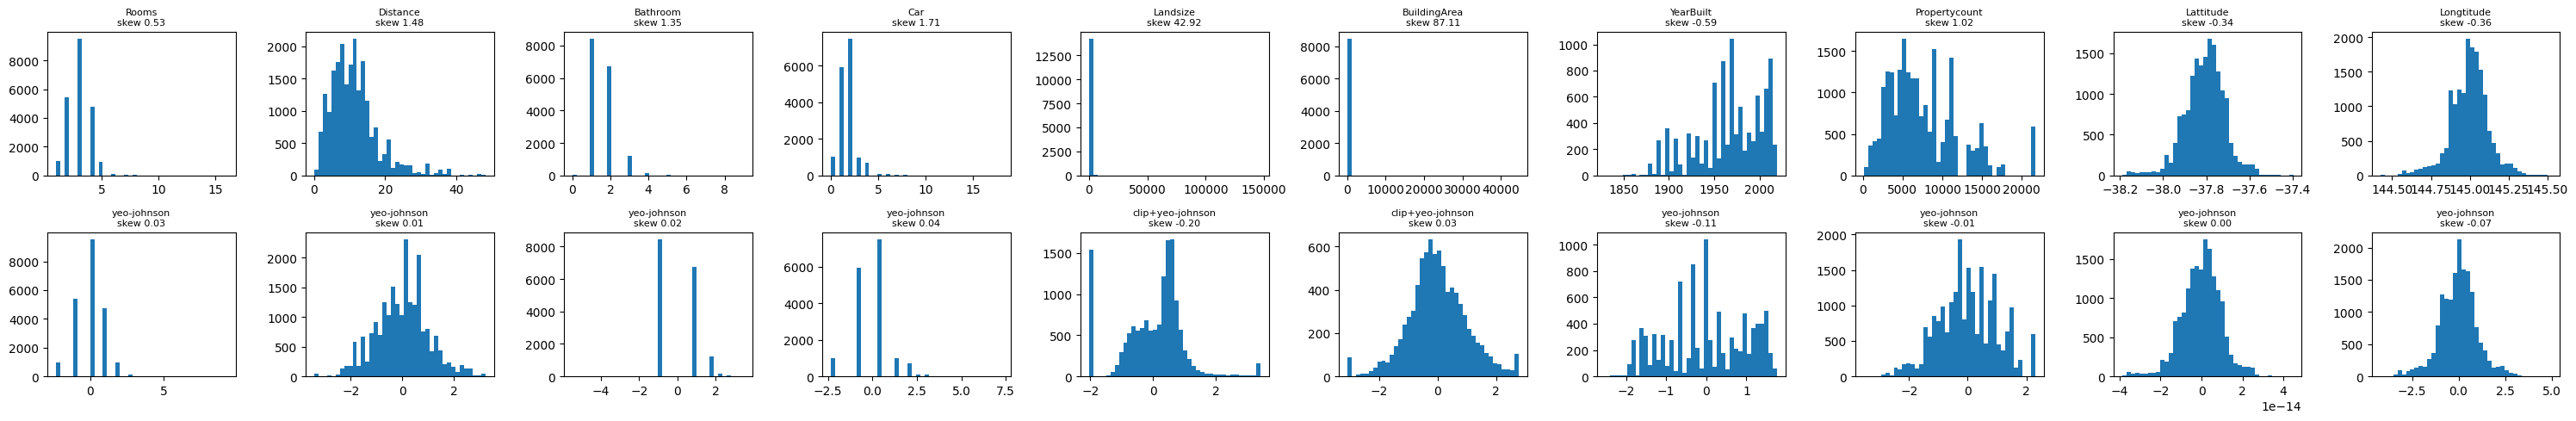

In [12]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer

num = ["Rooms","Distance","Bathroom","Car","Landsize","BuildingArea",
       "YearBuilt","Propertycount","Lattitude","Longtitude"]
# Bedroom2 and Postcode are dropped (R2), so they are not scaled.

def yj(s):  return pd.Series(PowerTransformer("yeo-johnson").fit_transform(s.to_frame()).ravel(), index=s.index)
def clip(s): return s.clip(s.quantile(.01), s.quantile(.99))

cands = {   # ordered simplest first
    "standard":        lambda s: s,
    "log1p":           lambda s: np.log1p(s) if (s >= 0).all() else pd.Series(np.nan, index=s.index),
    "clip+log1p":      lambda s: np.log1p(clip(s)) if (s >= 0).all() else pd.Series(np.nan, index=s.index),
    "yeo-johnson":     yj,
    "clip+yeo-johnson":lambda s: yj(clip(s)),
}

rows = []
for c in num:
    s = T[c].dropna()
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    r = {"column": c,
         "skew": s.skew(), "excess kurt": s.kurt(),
         "p99/median": s.quantile(.99) / s.median() if s.median() else np.nan,
         "max/p99": s.max() / s.quantile(.99) if s.quantile(.99) else np.nan,
         "outlier %": ((s < q1-1.5*iqr) | (s > q3+1.5*iqr)).mean() * 100}
    sk = {k: f(s).skew() for k, f in cands.items()}
    for k, v in sk.items(): r[f"skew: {k}"] = v
    # rule: simplest candidate whose |skew| is within 0.25 of the best one
    best = min(abs(v) for v in sk.values() if pd.notna(v))
    r["chosen"] = next(k for k, v in sk.items() if pd.notna(v) and abs(v) <= best + 0.25)
    rows.append(r)

scal = pd.DataFrame(rows).round(2)
pd.set_option("display.width", 250)
display(scal)

# distributions before/after (the proof for the write-up)
fig, ax = plt.subplots(2, len(num), figsize=(3*len(num), 5))
for i, c in enumerate(num):
    s = T[c].dropna(); ch = scal.loc[scal.column == c, "chosen"].iloc[0]
    ax[0, i].hist(s, bins=40); ax[0, i].set_title(f"{c}\nskew {s.skew():.2f}", fontsize=8)
    t = cands[ch](s); ax[1, i].hist(t, bins=40); ax[1, i].set_title(f"{ch}\nskew {t.skew():.2f}", fontsize=8)
plt.tight_layout(); plt.savefig("r4_distributions.png", dpi=120); plt.show()